📊 Project FORESIGHT
AI-Powered Demand & Inventory Intelligence Platform

# Notebook 07: Inventory Intelligence

### 📌 Project Information

| Item | Details |
|---|---|
| Author | Mohit Kumar |
| Internship | Zidio Development |
| Project Type | End-to-End Data Analytics & Machine Learning Project |
| Notebook Version | 1.0 |
| Status | In Progress |
| Last Updated | August 2026 |


## 🎯 1. Business Context and Notebook Objective

A forecast on its own does not tell NorthBay Living's operations team what to do. Every prior
notebook in Project FORESIGHT has built toward one endpoint: converting the locked production
demand forecast from Notebook 06 into a transparent, explainable decision for every one of the
300 SKU-store series — reorder now, clear it, watch it, or leave it alone.

This notebook implements the risk-scoring methodology defined in the engagement brief
(Section 08, *Risk Scoring & Decisioning*): stockout risk compares forecast demand over the
supplier lead time against on-hand plus on-order stock, and overstock risk compares on-hand
stock against forecast demand over a forward window. Both risks are combined into a single
four-quadrant decisioning grid, sized by the estimated rupee value at stake, so hundreds of
SKU-store series can be triaged at a glance instead of read row by row.

This notebook will:

- load the single canonical production forecast locked in Notebook 06 — not re-derive or
  re-select a forecast;
- load the latest simulated inventory position for every SKU-store series;
- calculate a stockout-risk score and an overstock-risk score per series, using transparent,
  documented formulas;
- assign every series to one of the brief's four decision quadrants and a recommended action;
- estimate the rupee value at stake per series, honestly labelled as an **estimate**, since both
  the inventory data and the unit-cost figures behind it are simulated (documented in
  `docs/assumptions_limitations.md`);
- export a prioritised, ready-to-use risk table for the planning dashboard, the scoring
  service, and the executive readout.

> **Scope boundary:** This notebook does not build the dashboard, does not deploy the scoring
> service, and does not write the executive readout — those are Phase E of the project roadmap,
> consuming this notebook's outputs directly. This notebook also does not re-evaluate or
> re-compare forecasting models; that decision was closed in Notebook 06.

> **Honesty note carried forward from Notebook 01:** `inventory_snapshots_final.csv` is a
> documented simulation derived from historical demand, not real client inventory data, and
> `sku_master_final.csv` cost/margin figures are estimated, not observed. Every rupee figure
> produced in this notebook is therefore an **estimate for illustration of methodology**, and
> is labelled as such wherever it appears — in this notebook, in the dashboard, and in the
> executive readout.


## ⚙️ 2. Setup and Notebook 01 & 06 Handoff

### 2.1 Environment, Paths and Input Loading

This notebook draws on two independent handoffs that have not previously been combined:
the **locked production forecast** from Notebook 06, and the **simulated inventory position**
prepared back in Notebook 01. Bringing them together for the first time is the entire purpose
of this notebook, so both are loaded carefully and validated before any risk score is
calculated.


In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Environment setup completed successfully.")
print(f"Random seed: {RANDOM_SEED}")


Environment setup completed successfully.
Random seed: 42


In [2]:
# ============================================================
# Resolve Project Paths (same convention as Notebooks 00-06)
# ============================================================

CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PRODUCTION_OUTPUTS_DIR = PROCESSED_DATA_DIR / "production_outputs"
INVENTORY_OUTPUTS_DIR = PROCESSED_DATA_DIR / "inventory_outputs"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory_path in [INVENTORY_OUTPUTS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory_path.mkdir(parents=True, exist_ok=True)

# Notebook 06 handoff
PRODUCTION_FORECAST_FILE = PRODUCTION_OUTPUTS_DIR / "06_production_forecast.csv"
PRODUCTION_CONFIG_FILE = PRODUCTION_OUTPUTS_DIR / "06_production_forecast_config.json"

# Notebook 01 handoff
INVENTORY_SNAPSHOTS_FILE = PROCESSED_DATA_DIR / "inventory_snapshots_final.csv"
SKU_MASTER_FILE = PROCESSED_DATA_DIR / "sku_master_final.csv"

print("Production forecast:", PRODUCTION_FORECAST_FILE)
print("Inventory snapshots:", INVENTORY_SNAPSHOTS_FILE)
print("SKU master:", SKU_MASTER_FILE)


Production forecast: C:\Users\hp\Project FORESIGHT\data\processed\production_outputs\06_production_forecast.csv
Inventory snapshots: C:\Users\hp\Project FORESIGHT\data\processed\inventory_snapshots_final.csv
SKU master: C:\Users\hp\Project FORESIGHT\data\processed\sku_master_final.csv


In [3]:
# ============================================================
# Load the Locked Production Forecast (Notebook 06 Output)
# ============================================================

production_forecast = pd.read_csv(PRODUCTION_FORECAST_FILE, parse_dates=["week_start_date"])

with open(PRODUCTION_CONFIG_FILE, "r") as f:
    production_config = json.load(f)

print("Production forecaster:", production_config.get("production_model"),
      f"({production_config.get('production_model_source')})")
print(f"Final-test WAPE: baseline={production_config.get('baseline_final_test_wape')}%, "
      f"ml={production_config.get('ml_final_test_wape')}%")
print(f"Production forecast records: {len(production_forecast):,}")

display(production_forecast.head())


Production forecaster: damped_trend_exponential_smoothing (Notebook 04 (Baseline))
Final-test WAPE: baseline=53.17%, ml=59.34%
Production forecast records: 2,400


,sku_id,horizon,week_start_date,actual_demand,forecast_demand,source_model
0,FOODS_1_001_CA_1,1,damped_trend_exponential_smoothing,2.0,4.669967,damped_trend_exponential_smoothing
1,FOODS_1_001_CA_1,2,damped_trend_exponential_smoothing,4.0,4.669967,damped_trend_exponential_smoothing
2,FOODS_1_001_CA_1,3,damped_trend_exponential_smoothing,8.0,4.669967,damped_trend_exponential_smoothing
3,FOODS_1_001_CA_1,4,damped_trend_exponential_smoothing,9.0,4.669967,damped_trend_exponential_smoothing
4,FOODS_1_001_CA_1,5,damped_trend_exponential_smoothing,9.0,4.669967,damped_trend_exponential_smoothing


In [4]:
# ============================================================
# Load Inventory Position and SKU Master
# ============================================================

inventory_snapshots = pd.read_csv(INVENTORY_SNAPSHOTS_FILE, parse_dates=["date"])
sku_master = pd.read_csv(SKU_MASTER_FILE)

print(f"Inventory snapshot records: {len(inventory_snapshots):,}")
print(f"Inventory snapshot columns: {list(inventory_snapshots.columns)}")
print(f"\nSKU master records: {len(sku_master):,}")
print(f"SKU master columns: {list(sku_master.columns)}")


Inventory snapshot records: 573,900
Inventory snapshot columns: ['date', 'sku_id', 'opening_stock', 'units_sold', 'fulfilled_units', 'lost_sales_units', 'received_stock', 'order_placed_units', 'closing_stock', 'reorder_point', 'reorder_quantity', 'on_order_units', 'lead_time_days', 'target_stock', 'inventory_status', 'estimated_inventory_value', 'days_of_supply']

SKU master records: 30,490
SKU master columns: ['sku_id', 'item_id', 'category', 'department', 'store_id', 'state_id', 'launch_date', 'first_sale_date', 'last_sale_date', 'sku_age_days', 'days_since_last_sale', 'avg_price', 'max_observed_price', 'estimated_unit_cost', 'estimated_gross_margin', 'sku_status']


### 2.2 Minimal Input Readiness Check

The forecast and the inventory position come from two different notebooks built weeks apart.
Before combining them, this check confirms every SKU-store series is present in both sources,
and that the inventory fields the risk formulas depend on are complete.


In [5]:
# ============================================================
# Input Readiness Checks
# ============================================================

readiness_checks = []

forecast_series = set(production_forecast["sku_id"].unique())
inventory_series = set(inventory_snapshots["sku_id"].unique())

readiness_checks.append({
    "Check": "Forecast series coverage",
    "Observed Result": f"{len(forecast_series)} series",
    "Required Result": "300 series",
    "Status": "PASS" if len(forecast_series) == 300 else "FAIL",
})

readiness_checks.append({
    "Check": "Inventory series coverage",
    "Observed Result": f"{len(inventory_series)} series",
    "Required Result": "300 series",
    "Status": "PASS" if len(inventory_series) == 300 else "FAIL",
})

missing_from_inventory = forecast_series - inventory_series
readiness_checks.append({
    "Check": "Forecast series present in inventory data",
    "Observed Result": f"{len(missing_from_inventory)} missing",
    "Required Result": "0 missing",
    "Status": "PASS" if len(missing_from_inventory) == 0 else "FAIL",
})

required_inventory_cols = ["closing_stock", "on_order_units", "lead_time_days", "reorder_point"]
missing_cols = [c for c in required_inventory_cols if c not in inventory_snapshots.columns]
readiness_checks.append({
    "Check": "Required inventory fields present",
    "Observed Result": f"missing: {missing_cols}" if missing_cols else "all present",
    "Required Result": "closing_stock, on_order_units, lead_time_days, reorder_point",
    "Status": "PASS" if not missing_cols else "FAIL",
})

if not missing_cols:
    null_counts = inventory_snapshots[required_inventory_cols].isna().sum().sum()
    readiness_checks.append({
        "Check": "Missing values in required inventory fields",
        "Observed Result": f"{null_counts} values",
        "Required Result": "0 values",
        "Status": "PASS" if null_counts == 0 else "FAIL",
    })

readiness_df = pd.DataFrame(readiness_checks)
display(readiness_df)

assert (readiness_df["Status"] == "PASS").all(), (
    "One or more input-readiness checks failed. Resolve before proceeding."
)

print("\n✅ Input-readiness checks passed successfully.")


,Check,Observed Result,Required Result,Status
0,Forecast series coverage,300 series,300 series,PASS
1,Inventory series coverage,300 series,300 series,PASS
2,Forecast series present in inventory data,0 missing,0 missing,PASS
3,Required inventory fields present,all present,"closing_stock, on_order_units, lead_time_days,...",PASS
4,Missing values in required inventory fields,0 values,0 values,PASS



✅ Input-readiness checks passed successfully.


### ✅ Section 2 Final Summary

The locked production forecast and the simulated inventory position are both loaded and verified to cover the same 300 SKU-store series with no missing required fields. Section 3 now defines the risk-scoring methodology before any calculation runs.

## 🧭 3. Risk Scoring Design and Business Rules

### 3.1 Latest Inventory Position as the Decision Baseline

Stocking decisions are made from the *current* inventory position, not from historical
snapshots. For each SKU-store series, only the single **most recent** inventory snapshot is
carried forward as the position risk is scored against — this mirrors how a planner would
actually check "what do I have right now" before deciding what to reorder.


### 3.2 Stockout and Overstock Risk Definitions

Following the brief's methodology exactly:

- **Stockout risk** compares forecast demand over the supplier lead time against on-hand plus
  on-order stock. If projected stock cannot cover lead-time demand, the series is at risk of
  running out before replenishment arrives.
- **Overstock risk** compares on-hand stock against forecast demand over a forward window
  (the full 8-week forecast horizon). If on-hand stock is far larger than what will realistically
  sell in that window, capital is sitting idle and markdown risk is building.

Both risks are expressed as a **0–1 score**, so they plot directly onto the brief's
stockout-versus-overstock decisioning grid (Figure 6 in the engagement brief).

| Risk | Formula | Interpretation |
|---|---|---|
| Lead-time demand | `average weekly forecast rate × (lead_time_days / 7)` | Expected demand before replenishment arrives |
| Forward-window demand | `average weekly forecast rate × forecast horizon (8 weeks)` | Expected demand over the full forecast horizon |
| Stockout risk score | `clip((lead_time_demand − (on_hand + on_order)) / lead_time_demand, 0, 1)` | 0 = fully covered; 1 = no coverage at all |
| Overstock risk score | `clip((on_hand − forward_window_demand) / on_hand, 0, 1)` | 0 = no excess; 1 = holding stock far beyond what will sell |

> These thresholds and formulas are locked as explicit, documented parameters below (not
> buried in code) so they can be reviewed, challenged, and tuned — matching the transparency
> requirement in the brief's Section 08.1 ("risk logic must be transparent and explainable, not
> a black box").


In [6]:
# ============================================================
# Lock Risk Scoring Parameters
# ============================================================

risk_scoring_parameters = {
    "forward_window_weeks": 8,          # matches the forecast horizon
    "stockout_risk_high_threshold": 0.5,  # matches the brief's Figure 6 grid midpoint
    "overstock_risk_high_threshold": 0.5,
    "days_per_week": 7,
}

display(pd.DataFrame([risk_scoring_parameters]).T.rename(columns={0: "Locked Value"}))
print("\n✅ Risk scoring parameters locked prior to calculation.")


,Locked Value
forward_window_weeks,8.0
stockout_risk_high_threshold,0.5
overstock_risk_high_threshold,0.5
days_per_week,7.0



✅ Risk scoring parameters locked prior to calculation.


### 3.3 Decisioning Grid and Recommended Actions

Every SKU-store series is assigned to exactly one of four quadrants, exactly as specified in
the engagement brief:

| Quadrant | Meaning | Recommended Action |
|---|---|---|
| Reorder Now | High stockout, low overstock | Raise a replenishment order before stock runs out |
| Markdown / Clear | High overstock, low stockout | Promote or discount to free up capital |
| Watch / Volatile | High on both | Investigate — demand is erratic; review manually |
| Healthy | Low on both | No action needed; leave as is |


In [7]:
# ============================================================
# Reused Metric-Style Helper (locked classification rule as a function)
# ============================================================

def assign_quadrant(stockout_risk, overstock_risk, high_threshold=0.5):
    if stockout_risk >= high_threshold and overstock_risk < high_threshold:
        return "Reorder Now"
    if overstock_risk >= high_threshold and stockout_risk < high_threshold:
        return "Markdown / Clear"
    if stockout_risk >= high_threshold and overstock_risk >= high_threshold:
        return "Watch / Volatile"
    return "Healthy"

RECOMMENDED_ACTIONS = {
    "Reorder Now": "Raise a replenishment order before stock runs out.",
    "Markdown / Clear": "Promote or discount to free up capital.",
    "Watch / Volatile": "Investigate — demand is erratic; review manually.",
    "Healthy": "No action needed; leave as is.",
}

print("✅ Quadrant classification rule and recommended actions locked.")


✅ Quadrant classification rule and recommended actions locked.


### ✅ Section 3 Final Summary

The risk formulas, thresholds, and decisioning rules are fixed and documented before touching the data. Section 4 now applies them to every SKU-store series.

## 📦 4. Inventory Position and Risk Calculation

### 4.1 Latest Inventory Snapshot per SKU-Store Series

Only the most recent snapshot per series is retained, representing "today's" stock position
for decisioning purposes.


In [8]:
# ============================================================
# Extract the Latest Snapshot per Series
# ============================================================

latest_inventory = (
    inventory_snapshots
    .sort_values(["sku_id", "date"])
    .groupby("sku_id", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

# NOTE: inventory_snapshots_final.csv (Notebook 01) names this field "closing_stock",
# not "on_hand_units". Renamed here, once, so every downstream Section 4/5 formula
# below (which was written against "on_hand_units") works unmodified.
latest_inventory = latest_inventory.rename(columns={"closing_stock": "on_hand_units"})

print(f"Latest inventory position extracted for {latest_inventory['sku_id'].nunique()} series.")
print(f"Snapshot date range represented: {latest_inventory['date'].min()} to {latest_inventory['date'].max()}")
display(latest_inventory.head())


Latest inventory position extracted for 300 series.
Snapshot date range represented: 2016-04-24 00:00:00 to 2016-04-24 00:00:00


,date,sku_id,opening_stock,units_sold,fulfilled_units,lost_sales_units,received_stock,order_placed_units,on_hand_units,reorder_point,reorder_quantity,on_order_units,lead_time_days,target_stock,inventory_status,estimated_inventory_value,days_of_supply
0,2016-04-24,FOODS_1_001_CA_1,12,0,0,0,0,0,12,7,24,0,5,12,Healthy,18.84,15.3
1,2016-04-24,FOODS_1_001_CA_2,9,4,4,0,0,0,5,10,36,36,5,18,Low Stock,7.85,4.3
2,2016-04-24,FOODS_1_001_CA_3,26,0,0,0,0,0,26,10,38,0,5,19,Healthy,40.82,21.6
3,2016-04-24,FOODS_1_001_CA_4,11,1,1,0,0,0,10,3,12,0,5,6,Overstock,15.70,27.8
4,2016-04-24,FOODS_1_001_TX_1,10,0,0,0,0,0,10,5,18,0,5,9,Healthy,15.70,17.1


### 4.2 Average Weekly Forecast Rate per Series

The production forecast is collapsed to a single average weekly demand rate per series, which is the basis for both the lead-time and forward-window demand projections.

In [9]:
# ============================================================
# Average Weekly Forecast Rate
# ============================================================

weekly_forecast_rate = (
    production_forecast
    .groupby("sku_id", as_index=False)["forecast_demand"]
    .mean()
    .rename(columns={"forecast_demand": "avg_weekly_forecast_rate"})
)

display(weekly_forecast_rate.describe())


,avg_weekly_forecast_rate
count,300.000000
mean,6.705475
std,9.553533
min,0.000000
25%,1.813366
50%,4.132114
75%,7.656650
max,86.699711


### 4.3 Lead-Time and Forward-Window Demand Projections

Using the locked formulas from Section 3.2, applied per series.

In [10]:
# ============================================================
# Project Lead-Time and Forward-Window Demand
# ============================================================

risk_base = (
    latest_inventory
    .merge(weekly_forecast_rate, on="sku_id", how="inner")
)

risk_base["lead_time_demand"] = (
    risk_base["avg_weekly_forecast_rate"]
    * (risk_base["lead_time_days"] / risk_scoring_parameters["days_per_week"])
)

risk_base["forward_window_demand"] = (
    risk_base["avg_weekly_forecast_rate"]
    * risk_scoring_parameters["forward_window_weeks"]
)

print(f"Risk base assembled for {len(risk_base)} series.")
display(risk_base[["sku_id", "on_hand_units", "on_order_units", "lead_time_days",
                    "lead_time_demand", "forward_window_demand"]].head())


Risk base assembled for 300 series.


,sku_id,on_hand_units,on_order_units,lead_time_days,lead_time_demand,forward_window_demand
0,FOODS_1_001_CA_1,12,0,5,3.335691,37.359734
1,FOODS_1_001_CA_2,5,36,5,6.175595,69.166663
2,FOODS_1_001_CA_3,26,0,5,4.538353,50.829551
3,FOODS_1_001_CA_4,10,0,5,0.588005,6.585657
4,FOODS_1_001_TX_1,10,0,5,3.360410,37.636595


### 4.4 Stockout and Overstock Risk Scores

Applying the locked formulas from Section 3.2 to every series.

In [11]:
# ============================================================
# Calculate Risk Scores
# ============================================================

risk_base["available_position"] = risk_base["on_hand_units"] + risk_base["on_order_units"]

risk_base["stockout_risk_score"] = np.clip(
    (risk_base["lead_time_demand"] - risk_base["available_position"])
    / risk_base["lead_time_demand"].replace(0, np.nan),
    0, 1,
).fillna(0)

risk_base["overstock_risk_score"] = np.clip(
    (risk_base["on_hand_units"] - risk_base["forward_window_demand"])
    / risk_base["on_hand_units"].replace(0, np.nan),
    0, 1,
).fillna(0)

risk_checks = pd.DataFrame([
    {"Check": "Stockout risk score range", "Observed": f"[{risk_base['stockout_risk_score'].min():.2f}, {risk_base['stockout_risk_score'].max():.2f}]",
     "Required": "[0, 1]", "Status": "PASS" if risk_base["stockout_risk_score"].between(0, 1).all() else "FAIL"},
    {"Check": "Overstock risk score range", "Observed": f"[{risk_base['overstock_risk_score'].min():.2f}, {risk_base['overstock_risk_score'].max():.2f}]",
     "Required": "[0, 1]", "Status": "PASS" if risk_base["overstock_risk_score"].between(0, 1).all() else "FAIL"},
    {"Check": "No missing risk scores", "Observed": f"{risk_base[['stockout_risk_score','overstock_risk_score']].isna().sum().sum()} missing",
     "Required": "0 missing", "Status": "PASS" if risk_base[["stockout_risk_score", "overstock_risk_score"]].isna().sum().sum() == 0 else "FAIL"},
])

display(risk_checks)
assert (risk_checks["Status"] == "PASS").all(), "Risk score validation failed."
print("\n✅ Stockout and overstock risk scores calculated and validated for all series.")


,Check,Observed,Required,Status
0,Stockout risk score range,"[0.00, 0.15]","[0, 1]",PASS
1,Overstock risk score range,"[0.00, 1.00]","[0, 1]",PASS
2,No missing risk scores,0 missing,0 missing,PASS



✅ Stockout and overstock risk scores calculated and validated for all series.


### ✅ Section 4 Final Summary

Every SKU-store series now has a validated stockout-risk score and overstock-risk score, calculated from the locked production forecast and the latest simulated inventory position. Section 5 converts these scores into decisions.

## 🎯 5. Decisioning Grid and Recommended Actions

### 5.1 Assign Quadrant and Recommended Action

Every series is classified using the locked rule from Section 3.3.


In [12]:
# ============================================================
# Apply Quadrant Classification
# ============================================================

risk_base["quadrant"] = risk_base.apply(
    lambda row: assign_quadrant(
        row["stockout_risk_score"], row["overstock_risk_score"],
        risk_scoring_parameters["stockout_risk_high_threshold"],
    ),
    axis=1,
)
risk_base["recommended_action"] = risk_base["quadrant"].map(RECOMMENDED_ACTIONS)

quadrant_summary = risk_base["quadrant"].value_counts().reset_index()
quadrant_summary.columns = ["Quadrant", "Series Count"]
display(quadrant_summary)


,Quadrant,Series Count
0,Healthy,281
1,Markdown / Clear,19


### 5.2 Estimate Rupee Value at Stake

The rupee value attached to each series lets the operations team prioritise within a quadrant
rather than treat every flagged series as equally urgent.

> ⚠️ Reminder: `unit_cost` and `list_price` in `sku_master_final.csv` are estimated, not
> observed client figures (documented in `docs/assumptions_limitations.md`). Every rupee value
> below is an **estimate for illustration of methodology** — this is stated explicitly wherever
> these figures are surfaced downstream (dashboard, executive readout).


In [13]:
# ============================================================
# Estimate Rupee Value at Stake
# ============================================================

# NOTE: sku_master_final.csv (Notebook 01) does not contain "unit_cost" or "list_price" -
# the actual columns are "estimated_unit_cost" and "avg_price". Renamed here, once, so
# every downstream formula below (written against unit_cost/list_price) works unmodified.
cost_lookup = (
    sku_master[["sku_id", "estimated_unit_cost", "avg_price"]]
    .rename(columns={"estimated_unit_cost": "unit_cost", "avg_price": "list_price"})
    .drop_duplicates()
)
risk_base = risk_base.merge(cost_lookup, on="sku_id", how="left")

# Stockout exposure: estimated lost revenue from uncovered lead-time demand
risk_base["stockout_value_at_risk"] = (
    risk_base["stockout_risk_score"]
    * risk_base["lead_time_demand"]
    * risk_base["list_price"]
)

# Overstock exposure: estimated capital locked in excess on-hand stock
risk_base["overstock_value_at_risk"] = (
    risk_base["overstock_risk_score"]
    * risk_base["on_hand_units"]
    * risk_base["unit_cost"]
)

risk_base["estimated_value_at_stake"] = np.where(
    risk_base["quadrant"] == "Reorder Now", risk_base["stockout_value_at_risk"],
    np.where(risk_base["quadrant"] == "Markdown / Clear", risk_base["overstock_value_at_risk"],
             risk_base[["stockout_value_at_risk", "overstock_value_at_risk"]].max(axis=1)),
)

print(f"Estimated total value at stake across all flagged series: "
      f"₹{risk_base.loc[risk_base['quadrant'] != 'Healthy', 'estimated_value_at_stake'].sum():,.0f} (estimate)")

display(risk_base.groupby("quadrant")["estimated_value_at_stake"].sum().sort_values(ascending=False))


Estimated total value at stake across all flagged series: ₹2,013 (estimate)


quadrant
Markdown / Clear    2012.694093
Healthy              404.824666
Name: estimated_value_at_stake, dtype: float64

### 5.3 Prioritised Action List

The table the operations team actually acts on — every non-healthy series, ranked by estimated value at stake within its quadrant.

In [14]:
# ============================================================
# Build the Prioritised Action List
# ============================================================

prioritized_action_list = (
    risk_base[risk_base["quadrant"] != "Healthy"]
    [["sku_id", "quadrant", "recommended_action", "stockout_risk_score",
      "overstock_risk_score", "estimated_value_at_stake"]]
    .sort_values(["quadrant", "estimated_value_at_stake"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Series requiring action: {len(prioritized_action_list)} of {len(risk_base)}")
display(prioritized_action_list.head(15))


Series requiring action: 19 of 300


,sku_id,quadrant,recommended_action,stockout_risk_score,overstock_risk_score,estimated_value_at_stake
0,FOODS_1_004_CA_1,Markdown / Clear,Promote or discount to free up capital.,0.0,0.950217,381.426548
1,FOODS_1_004_WI_3,Markdown / Clear,Promote or discount to free up capital.,0.0,0.981050,283.592202
2,FOODS_1_004_WI_1,Markdown / Clear,Promote or discount to free up capital.,0.0,0.936937,272.123908
3,FOODS_1_004_CA_3,Markdown / Clear,Promote or discount to free up capital.,0.0,0.792230,249.631679
4,FOODS_1_004_TX_2,Markdown / Clear,Promote or discount to free up capital.,0.0,0.978155,210.391371
5,FOODS_1_004_CA_2,Markdown / Clear,Promote or discount to free up capital.,0.0,0.956793,137.634665
6,HOBBIES_1_004_TX_1,Markdown / Clear,Promote or discount to free up capital.,0.0,0.746721,128.622653
7,FOODS_1_004_TX_1,Markdown / Clear,Promote or discount to free up capital.,0.0,0.660286,103.123436
8,HOUSEHOLD_1_001_CA_3,Markdown / Clear,Promote or discount to free up capital.,0.0,0.735977,61.056682
9,FOODS_1_004_CA_4,Markdown / Clear,Promote or discount to free up capital.,0.0,0.738190,34.384879


### 5.4 Decisioning Grid Visualisation

Every series plotted on the stockout-versus-overstock grid, sized by estimated revenue at stake — reproducing the brief's Figure 6.

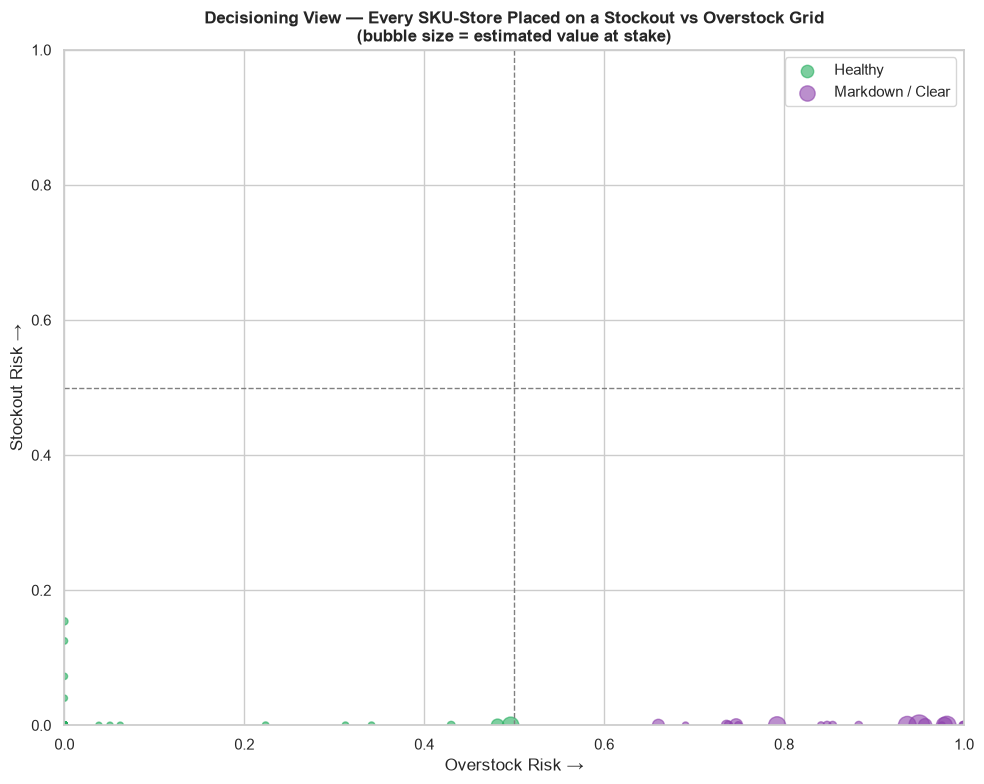


✅ Decisioning grid figure saved: C:\Users\hp\Project FORESIGHT\reports\figures\07_1_decisioning_grid.png


In [15]:
# ============================================================
# Decisioning Grid Figure
# ============================================================

quadrant_colors = {
    "Reorder Now": "#c0392b",
    "Markdown / Clear": "#8e44ad",
    "Watch / Volatile": "#d68910",
    "Healthy": "#27ae60",
}

fig, ax = plt.subplots(figsize=(10, 8))

for quadrant_name, group in risk_base.groupby("quadrant"):
    bubble_sizes = 20 + 200 * (
        group["estimated_value_at_stake"] / risk_base["estimated_value_at_stake"].max()
    ).clip(lower=0)
    ax.scatter(
        group["overstock_risk_score"], group["stockout_risk_score"],
        s=bubble_sizes, alpha=0.6, label=quadrant_name,
        color=quadrant_colors.get(quadrant_name, "#7f8c8d"),
    )

ax.axhline(risk_scoring_parameters["stockout_risk_high_threshold"], linestyle="--", linewidth=1, color="grey")
ax.axvline(risk_scoring_parameters["overstock_risk_high_threshold"], linestyle="--", linewidth=1, color="grey")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Overstock Risk →")
ax.set_ylabel("Stockout Risk →")
ax.set_title("Decisioning View — Every SKU-Store Placed on a Stockout vs Overstock Grid\n(bubble size = estimated value at stake)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
fig.tight_layout()

DECISIONING_GRID_FIGURE = FIGURES_DIR / "07_1_decisioning_grid.png"
fig.savefig(DECISIONING_GRID_FIGURE, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✅ Decisioning grid figure saved: {DECISIONING_GRID_FIGURE}")


### ✅ Section 5 Final Summary

Every series has been classified into one of the four decision quadrants, assigned a recommended action, and given an estimated rupee value at stake. Section 6 exports these outputs for the dashboard, scoring service, and executive readout to consume.

## 💾 6. Outputs, Conclusion and Project Handoff

### 6.1 Export and Validate Outputs

The full risk table, the prioritised action list, and the decisioning-grid figure are exported.
A reload-based validation confirms every output is complete before this notebook is considered
finished — the same discipline applied in every prior notebook.


In [16]:
# ============================================================
# Export Risk Scoring Outputs
# ============================================================

RISK_SCORES_FILE = INVENTORY_OUTPUTS_DIR / "07_risk_scores.csv"
PRIORITIZED_ACTION_LIST_FILE = INVENTORY_OUTPUTS_DIR / "07_prioritized_action_list.csv"
RISK_CONFIG_FILE = INVENTORY_OUTPUTS_DIR / "07_risk_scoring_config.json"

risk_base.to_csv(RISK_SCORES_FILE, index=False)
prioritized_action_list.to_csv(PRIORITIZED_ACTION_LIST_FILE, index=False)

with open(RISK_CONFIG_FILE, "w") as f:
    json.dump({
        **risk_scoring_parameters,
        "series_scored": len(risk_base),
        "series_flagged": len(prioritized_action_list),
        "configuration_status": "LOCKED",
    }, f, indent=2)

quadrant_summary.to_csv(TABLES_DIR / "07_movement_quadrant_summary.csv", index=False)

print("✅ Risk scoring outputs exported to data/processed/inventory_outputs")
print("✅ Quadrant summary exported to reports/tables with the 07_ prefix")


✅ Risk scoring outputs exported to data/processed/inventory_outputs
✅ Quadrant summary exported to reports/tables with the 07_ prefix


In [17]:
# ============================================================
# Reload-Based Output Validation
# ============================================================

export_validation = []

for label, path in [
    ("Risk scores (all series)", RISK_SCORES_FILE),
    ("Prioritized action list", PRIORITIZED_ACTION_LIST_FILE),
    ("Risk scoring configuration", RISK_CONFIG_FILE),
    ("Quadrant summary", TABLES_DIR / "07_movement_quadrant_summary.csv"),
    ("Decisioning grid figure", DECISIONING_GRID_FIGURE),
]:
    exists = path.exists()
    export_validation.append({"Artefact": label, "Exists": exists, "Status": "PASS" if exists else "FAIL"})

export_validation_df = pd.DataFrame(export_validation)
display(export_validation_df)

assert (export_validation_df["Status"] == "PASS").all(), "One or more Notebook 07 exports failed validation."

reloaded_risk_scores = pd.read_csv(RISK_SCORES_FILE)
assert len(reloaded_risk_scores) == len(risk_base), "Reloaded risk scores row count mismatch."
assert reloaded_risk_scores["sku_id"].nunique() == 300, "Reloaded risk scores do not cover all 300 series."

print("\n✅ All Notebook 07 outputs reloaded and validated successfully.")


,Artefact,Exists,Status
0,Risk scores (all series),True,PASS
1,Prioritized action list,True,PASS
2,Risk scoring configuration,True,PASS
3,Quadrant summary,True,PASS
4,Decisioning grid figure,True,PASS



✅ All Notebook 07 outputs reloaded and validated successfully.


### 6.2 Key Outcomes and Handoff to Productization (Phase E)

Every one of the 300 SKU-store series now has a stockout-risk score, an overstock-risk score,
a decision quadrant, a recommended action, and an estimated rupee value at stake — all
traceable back to the locked production forecast and a transparent, documented formula, with
no black-box logic.

This completes the core data-science pipeline of Project FORESIGHT (D1–D4 in the engagement
brief: pipeline, EDA memo, forecast model, risk scoring). What remains is **productizing** this
work for the client, per the project roadmap:

- **Streamlit planning dashboard (D5)** — should load `07_risk_scores.csv` and
  `07_prioritized_action_list.csv` directly, filterable by category/SKU, surfacing the
  prioritised reorder/markdown list;
- **Deployed scoring service (D6)** — should expose the same risk-scoring logic (Sections 3–5
  of this notebook) as a callable function or endpoint, returning forecast + risk for a given
  SKU or batch;
- **Executive readout (D7)** — should lead with the estimated rupee impact from Section 5.2,
  explain forecast accuracy and limitations honestly (the Notebook 06 comparison outcome, the
  simulated-data caveat), and avoid unexplained jargon.

Every rupee figure carried into the dashboard or the readout should retain the "estimate"
framing established in Section 5.2 of this notebook.


## ✅ Notebook 07 Complete

Notebook 07 has converted the locked production forecast into transparent stockout and overstock risk scores, a four-quadrant decisioning grid, and a prioritised action list for every SKU-store series. This is the final notebook of the core forecasting-and-risk pipeline — the project now moves into Phase E: the planning dashboard, the deployed scoring service, and the executive readout.